<a href="https://colab.research.google.com/github/AkhilKrishna016/fake-news-detection-ml/blob/main/fake_news_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Fake News Detection using Machine Learning

 **Model 1: Logistic Regressionn**

In [23]:
import pandas as pd
import numpy as np
np.random.seed(42)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [24]:
import pandas as pd

df = pd.read_csv("/content/sample_data/fake_and_real_news_dataset.csv")

df.head()

,idd,title,text,label
0,Fq+C96tcx+,‘A target on Roe v. Wade ’: Oklahoma bill maki...,UPDATE: Gov. Fallin vetoed the bill on Friday....,REAL
1,bHUqK!pgmv,Study: women had to drive 4 times farther afte...,Ever since Texas laws closed about half of the...,REAL
2,4Y4Ubf%aTi,"Trump, Clinton clash in dueling DC speeches","Donald Trump and Hillary Clinton, now at the s...",REAL
3,_CoY89SJ@K,Grand jury in Texas indicts activists behind P...,A Houston grand jury investigating criminal al...,REAL
4,+rJHoRQVLe,"As Reproductive Rights Hang In The Balance, De...",WASHINGTON -- Forty-three years after the Supr...,REAL


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   idd     4594 non-null   object
 1   title   4593 non-null   object
 2   text    4594 non-null   object
 3   label   4594 non-null   object
dtypes: object(4)
memory usage: 143.7+ KB


In [26]:
X = df['text']
y = df['label']

In [27]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X = vectorizer.fit_transform(X)

In [28]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [29]:
# 80-20
model_80 = LogisticRegression()
model_80.fit(X_train_80, y_train_80)

LogisticRegression()

In [41]:
# ---------- 80-20 ----------

predictions_80 = model_80.predict(X_test_80)

accuracy_80 = accuracy_score(y_test_80, predictions_80)

print("Logistic Regression Accuracy (80-20):", accuracy_80)

Logistic Regression Accuracy (80-20): 0.9085963003264418


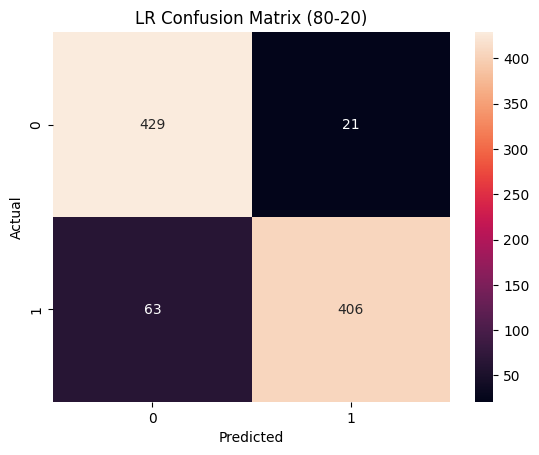

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_80 = confusion_matrix(y_test_80, predictions_80)

sns.heatmap(cm_80, annot=True, fmt='d')
plt.title("LR Confusion Matrix (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
# ---------- 70-30 ----------

model_70 = LogisticRegression()
model_70.fit(X_train_70, y_train_70)

predictions_70 = model_70.predict(X_test_70)

accuracy_70 = accuracy_score(y_test_70, predictions_70)

print("Logistic Regression Accuracy (70-30):", accuracy_70)

Logistic Regression Accuracy (70-30): 0.902102973168963


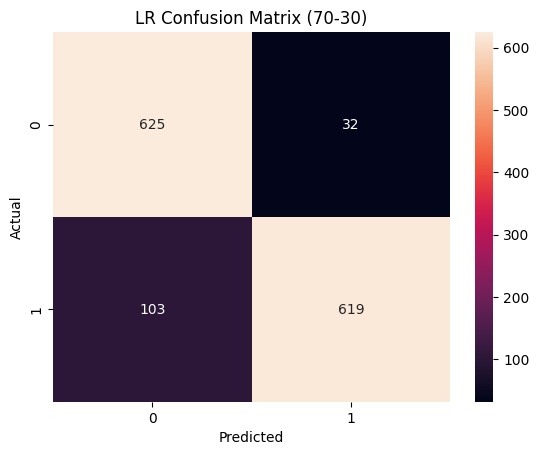

In [44]:
cm_70 = confusion_matrix(y_test_70, predictions_70)

sns.heatmap(cm_70, annot=True, fmt='d')
plt.title("LR Confusion Matrix (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**## Model 2: Support Vector Machine (SVM)**


In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

In [33]:
svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9292709466811752


In [34]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

        FAKE       0.91      0.96      0.93       450
        REAL       0.95      0.90      0.93       469

    accuracy                           0.93       919
   macro avg       0.93      0.93      0.93       919
weighted avg       0.93      0.93      0.93       919



**Model 3: Decision Tree Classifier**


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [36]:
dt_model = DecisionTreeClassifier(random_state=42)

In [37]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
dt_predictions = dt_model.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.8291621327529923


In [40]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

        FAKE       0.82      0.83      0.83       450
        REAL       0.84      0.83      0.83       469

    accuracy                           0.83       919
   macro avg       0.83      0.83      0.83       919
weighted avg       0.83      0.83      0.83       919

